Numerical calculations: float-point arithmetic

Symbolic programming: tree-graph 

Interval programming: interval arithmetic 

In [78]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [79]:
x_sym = sp.symbols('x') 
expr = x_sym**2 - 2 
sol = sp.solveset(expr, x_sym , domain=sp.Interval(-0.5,2))
print(sol)

{sqrt(2)}


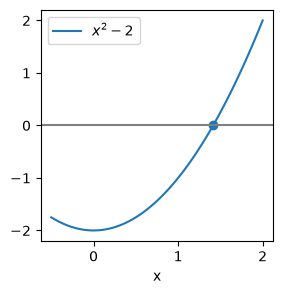

In [80]:
x = np.linspace(-0.5, 2, 100)
y_sym = sp.lambdify(x_sym, expr, 'numpy')
y = y_sym(x)

fig,ax = plt.subplots(figsize=(3,3))
ax.plot(x,y, "-", label=r"$x^2 - 2$")
ax.axhline(0, color="gray")
ax.scatter(float(sol.args[0]), 0)
ax.set_xlabel("x")
ax.legend()
plt.show()


# Intermediate Value  theorem



In [81]:
def bisection(func, a, b, tol= 1e-7, maxiter =100): 
    if a >= b :
        raise ValueError("a should be less than b")
    fa = func(a)
    fb = func(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("f(a) and f(b) should have different signs")
    c= np.inf
    hist = []
    for iter in range(maxiter):
        c = a + (b - a) / 2. # c= (a+b)/2  
        fc = func(c)
        hist.append(c)
        if np.sign(fa) == np.sign(fc):
            a = c
            fa = fc
        elif np.sign(fb) == np.sign(fc):
            b = c
            fb = fc
        if np.abs(b-a) <tol:
            break
    return c, hist
        

Root: 1.4142135232686996, error: 3.910439549947853e-08


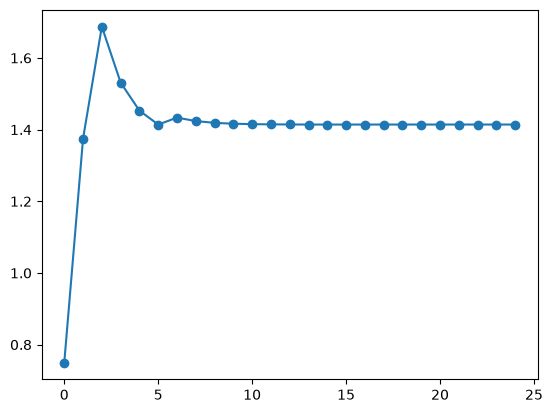

In [84]:
def my_func(x):
    return x**2 - 2
root, hist = bisection(my_func, -0.5, 2.0, tol= 1e-7, maxiter =100)
print(f"Root: {root}, error: {abs(root - np.sqrt(2))}")

plt.plot(hist, '-o')
plt.show()